# Data Science ODL Project: Assessment 2

- **Student ID**: 2016692702
- **Name**: Wesley Chiu
- **User ID**: od22wc

## Case study

Refer to the brief

## 1. Aims, objectives and plan (4 marks)

### a) Aims and objectives
Although we have already stated what is required, please formally state the aims and objectives of the project in your own words.

100-200 words

**Aim**

The client would like to reduce the cost of fraud to their business by leveraging historical data to predict whether an existing customer submitting a claim is like to be a fraudulent claim, while also ensuring that the risk of mistakenly accusing a genuine client of being fraudulent is kept at a minimum.

**Objective**

The objective of this project will be to use historical data to create a classification data model to label whether an existing client is fraudulent or not; this model should aim to have a balanced error rate of no more than 5%. Once this data model has been trained and an error rate has been derived, the impact to the business will need to be assessed. This will be achieved by comparing the cost of fraud (i.e. no mitigating factors) to the cost of using the model (i.e. cost of mistakenly accusing genuine customers of being fraudulent). Finally, a recommendation will be made to the business whether it should adopt the outputs of the model or not.

###  b) Plan
Please demonstrate how you have conducted the project with a simple Gantt chart.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [2]:
# The high-level project plan data
df_gantt = pd.DataFrame(
                {'Phase' : ['Read and understand Case Study', 'Data Wrangling', 'Model Trialling / Prototyping', 'Model Selection', 'Model Testing', 'Assessing Business Cost Impact', 'Final Recommendations', 'Formatting Assessment Outputs'],
                 'Start' : ['2022-12-07', '2022-12-08', '2022-12-11', '2022-12-14', '2022-12-15', '2022-12-16', '2022-12-17', '2022-12-18'],
                 'Duration' : [1, 3, 3, 2, 2, 1, 1, 1]})
df_gantt['Start'] = pd.to_datetime(df_gantt['Start'])
df_gantt['Duration'] = pd.to_timedelta(df_gantt['Duration'], unit='D')
df_gantt = df_gantt.iloc[::-1]

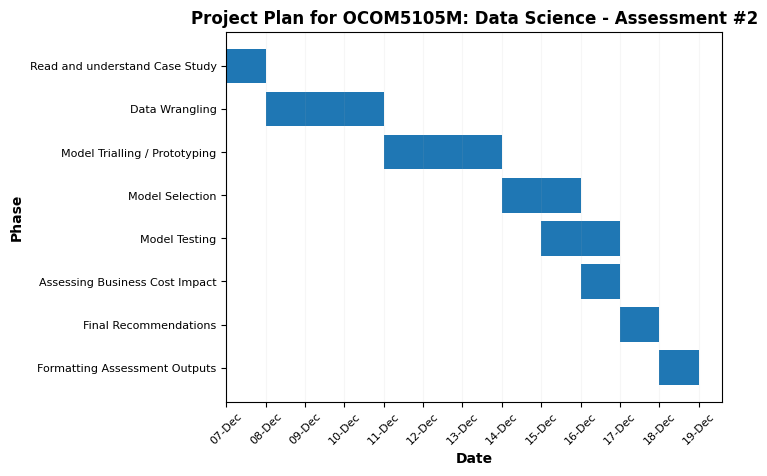

In [3]:
# Creating the xaxis tick labels
dates = pd.date_range(start='2022-12-06', end='2022-12-19')

# Creating the chart
fig, ax = plt.subplots()
ax.set_xticks(dates)
ax.barh(y=df_gantt['Phase'], width=df_gantt['Duration'], left=df_gantt['Start'])
ax.set_xticklabels(dates, rotation=45)

# Formatting Chart Output
date_format = DateFormatter('%d-%b')
ax.xaxis.set_major_formatter(date_format)
ax.xaxis.grid(True, alpha=0.1)

ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Phase', fontweight='bold')
plt.title('Project Plan for OCOM5105M: Data Science - Assessment #2', fontweight='bold')

plt.show()

## 2. Understanding the case study (4 marks)

###  Case study analysis
State the key points that you found in the case and how you intend to deal with them appropriately to address the client's needs. (You can include more than four points.)

200-300 words

1. Goal is to use historic fraud data to determine whether a customer is likely to be fraudulent or not when making a claim
 - This type of problem presents as a classification problem
 - As we have a limited number of datapoints (i.e. we do not have an extremely large set of datapoints), we will need to train, validate, and test the models leveraging cross-validation
2. The client wishes to aim for an error rate at or below 5%
 - We will need to ensure that the generalisation error rate is minimalised
 - Given our limited dataset, this lends itself to using nested-cross validation
3. Error rate 'goal' is provided as the client wishes to minimise impact of lost revenue due to misclassification
 - Providing an error rate goal will not be sufficient to communicate the benefits (or cost) of this model
 - A meaningful conclusion and recommendation will include the financial impact to the business' profit
4. Historical fraud data will be provided as the training and test data
 - This implies that there will be some data cleaning to do, as historical data may not complete enough for data analysis
 - We will need also need to combine disparate datasets together in order to 'emulate' the type of data the business has access to before a case is flagged as 'fraudulent' or not

## 3. Pre-processing applied (20 marks)
Enter the code in the cells below to execute each of the stated sub-tasks. 


In [4]:
# Report settings
pd.set_option('display.max_columns', None)
hs = 2 # dataframe head size - controls the number of rows to print; defaulted at 2 for compactness
n_jobs = -1 # setting number of jobs to take advantage of multi-core processors

### Joining the data together to form a single dataset

In [5]:
list_filenames = ['Train_Demographics', 'Train_Claim', 'Train_Policy', 'Train_Vehicle', 'Traindata_with_Target']
list_df = []

for count, filename in enumerate(list_filenames):
    list_df.append(pd.read_csv(f'Datasets\\{filename}.csv'))
    list_df[count].name = filename

print(f'Checking file dimensions to ensure all are the same:')
for df in list_df:
    print(f'{df.name}: {df.shape}')

Checking file dimensions to ensure all are the same:
Train_Demographics: (28836, 10)
Train_Claim: (28836, 19)
Train_Policy: (28836, 10)
Train_Vehicle: (115344, 3)
Traindata_with_Target: (28836, 2)


In [6]:
# Pivoting 'Train_Vehicle' to structure the data in line with the other files
list_index = list_filenames.index('Train_Vehicle')
df = list_df[list_index]

df = df.pivot(index='CustomerID',columns='VehicleAttribute', values='VehicleAttributeDetails')
print(df.shape)
list_df[list_index] = df
df.head(hs)

(28836, 4)


VehicleAttribute,VehicleID,VehicleMake,VehicleModel,VehicleYOM
CustomerID,,,,
Cust10000,Vehicle26917,Audi,A5,2008
Cust10001,Vehicle15893,Audi,A5,2006


Now that all datasets are of a similar structure, we can join the datasets.
We start by assigning "CustomerID" as the index for these dataframes - note that this means that we have made the decision that CustomerID is not correlated with ReportedFraud.

In [7]:
# Checking to see if we can join on CustomerID

if len(list_df[1]['CustomerID'].value_counts()) == len(list_df[1]):
    print('CustomerID is unique for each row of the dataset - it can be used as the index')
else:
    print('Error - duplicate CustomerID detected')


CustomerID is unique for each row of the dataset - it can be used as the index


In [8]:
# Assigning 'CustomerID' as the index for all dataframes
for df in list_df:
    if df.index.name != 'CustomerID': df.set_index('CustomerID', inplace=True)

# Joining the dataframes to the first dataframe
df_joined = list_df[0].join(list_df[1:], how='left')
print(f'Combined dataset size: {df_joined.shape}')
df_joined.head(hs)

Combined dataset size: (28836, 41)


,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,Country,DateOfIncident,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentState,IncidentCity,IncidentAddress,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,AmountOfInjuryClaim,AmountOfPropertyClaim,AmountOfVehicleDamage,InsurancePolicyNumber,CustomerLoyaltyPeriod,DateOfPolicyCoverage,InsurancePolicyState,Policy_CombinedSingleLimit,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleID,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,454776,MALE,JD,armed-forces,movies,56700,-48500,India,2015-02-03,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City1,Location 1311,17,3,?,1,0,?,65501,13417,6071,46013,119121,49,1998-10-25,State1,100/300,1000,1632.73,0,not-in-family,Vehicle26917,Audi,A5,2008,N
Cust10001,36,454776,MALE,JD,tech-support,cross-fit,70600,-48500,India,2015-02-02,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City5,Location 1311,10,3,YES,2,1,YES,61382,15560,5919,39903,119122,114,2000-11-15,State1,100/300,1000,1255.19,0,not-in-family,Vehicle15893,Audi,A5,2006,N


### Checking for potential class imbalance
Before we drop any rows to account for missing data, we should check if there is any class imbalance

Percentage of Customers with Reported Fraud: 27.0%


<Axes: xlabel='ReportedFraud'>

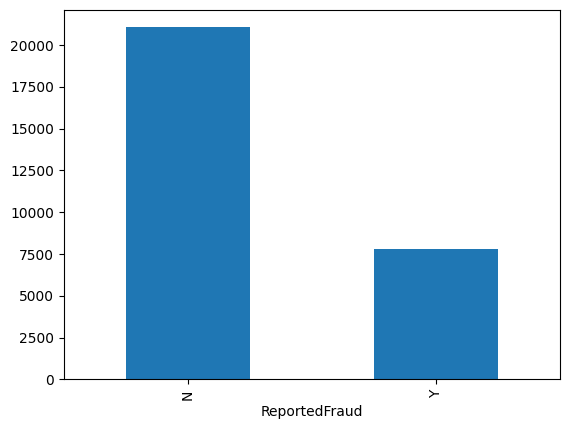

In [9]:
df_grouped = df_joined.groupby(['ReportedFraud'])['InsurancePolicyNumber'].count()
print(f'Percentage of Customers with Reported Fraud: {round((df_grouped["Y"]/df_grouped.sum())*100, 2)}%')
df_grouped.plot.bar()

As we can see, we do have some class imbalance here.
Instead of oversampling the minority class, however, we will deal with it by choosing techniques that are either less impacted by imbalance (e.g. MLPClassifier) or one that has the in-built ability in sklearn to correct this through weighting (e.g. LogisticRegression)

###  c) Dealing with missing values if necessary 


#### Finding features with missing data
 - We know from the data descriptions that there are missing data
     - InsuredGender: NaN
     - ContractType: "NA" --> this field does not exist in dataset
     - TypeOfCollission: "?"
     - IncidentTime: -5
     - PropertyDamage: "?"
     - Witnesses: "MISSINGVALUE"
     - PoliceReport: "?"
     - AmountOfTotalClaim: "MISSEDDATA"
     - VehicleAttributeDetails: "???"
 - We could have determined the above by calling df.value_counts() for each column of the dataframe, but we have excluded it here for compactness of the report
 - While some of the missing data will be useful to capture as additional information, we will first cast all missing data to the np.NaN type

In [10]:
# Replacing the only numerical "missing" data first
df_joined['IncidentTime'].replace(-5, np.NaN, inplace=True)

# Replacing all the missing values that are populated with strings
missing_values = ['MISSINGVALUE', 'MISSEDDATA', '?', '???']
df_joined.replace(missing_values, np.NaN, inplace=True)

df_missing = pd.Series(df_joined.isnull().sum())
print(df_missing[df_missing>0])

InsuredGender              30
Country                     2
TypeOfCollission         5162
AuthoritiesContacted     2692
IncidentTime               31
PropertyDamage          10459
Witnesses                  46
PoliceReport             9805
AmountOfTotalClaim         50
VehicleMake                50
dtype: int64


#### Dealing with missingness from a few small datapoints
The following features have missing data that consists of only a fraction of the total dataset: <br> InsuredGender, Country, IncidentTime, Witnesses, AmountOfTotalClaim, VehicleMake

As the change to dataset size is immaterial, we can confidently drop those datapoints without affecting the analysis.

In [11]:
# Storing in a new dataframe for ease of re-running the cell
df_dropped = df_joined.dropna(subset=['InsuredGender', 'Country', 'IncidentTime', 'Witnesses', 
                                     'AmountOfTotalClaim', 'VehicleMake'])

print(f'We have reduced the total number of rows by: {len(df_joined) - len(df_dropped)}')
print(f'This has resulted in a {round((1-len(df_dropped)/len(df_joined))*100, 2)}% reduction in dataset size')

We have reduced the total number of rows by: 128
This has resulted in a 0.44% reduction in dataset size


#### Dealing with material missingness
Missingness from other attributes cannot be dealt with in the same way, as this would affect the dataset too much.
Instead of ignoring the attribute, we will treat the 'Missing' data as a type of category, as we don't know whether the presence (or not) of the data is correlated to the ReportedFraud field. We can test this assumption later.

In [12]:
# Checking again to see which fields are most affected
df_missing = df_dropped.isnull().sum()
df_missing = df_missing[df_missing>0]

df_missing = round(df_missing / len(df_dropped)*100, 2)

print(f'% of total dataset missing these fields:')
print(df_missing)

% of total dataset missing these fields:
TypeOfCollission        17.90
AuthoritiesContacted     9.33
PropertyDamage          36.27
PoliceReport            34.02
dtype: float64


###  b) Removing synonymous and noisy attributes if necessary 


#### Feature Creation and Extraction
Examining some of the features, we can see that there is an opportunity to create new features that are more relevant for the analysis, namely:

- **CapitalProfit**: it may be easier for the model to correlate the net loss or gain of capital by combining the two columns
- **Policy_LowerSingleLimit** & **Policy_UpperSingleLimit**: 'Policy_CombinedSingleLimit' is a string value that appears to denote two separate values, which we can separate here

In [13]:
df = df_dropped.copy(deep=True)
df['CapitalProfit'] = df['CapitalGains'] + df['CapitalLoss']
df[['Policy_LowerSingleLimit', 'Policy_UpperSingleLimit']] = df['Policy_CombinedSingleLimit'].str.split('/', expand=True)

#### Dimensionality Reduction
Now that we have additional features extracted, we can begin the process of removing certain features that may be obviously redundant or similar:
 - **Country**: Examining the data, it suggests that we only have data belonging to 'India', so our model must either by relevant only to India, or it must classify independently of country; therefore, we can drop this
 - **DateOfIncident** and **DateOfPolicyCoverage**: The exact historical date won't help us with future datapoints
 - **IncidentState** and **IncidentAddress**: It is unlikely that we need the Address itself, and having the **IncidentCity** will already inform the **IncidentState**; therefore these two are redundant / synonymous
 - **AmountOfInjuryClaim, AmountOfPropertyClaim, AmountOfVehicleDamage**: These are all the component parts of **AmountOfTotalClaim**, so we remove these
 - **InsurancePolicyNumber**: We can see that this is a unique identifier per customer, just like **CustomerID**, therefore we can drop this as we are already using **CustomerID** as the index
 - **Policy_CombinedSingleLimit**: We have split this out into two features, so we can remove this redundant column
 - **VehicleID**: The unique identifier for each vehicle covered is unlikely to be correlated with Fraud, so we can drop this

In [14]:
# Testing country
print(df['Country'].value_counts())

# Testing InsurancePolicyNumber
print(f'One InsurancePolicyNumber for each CustomerID? {len(df)==len(df["InsurancePolicyNumber"].unique())}')

# Testing VehicleID
print(f'One VehicleID for each CustomerID? {len(df)==len(df["VehicleID"].unique())}')

Country
India    28708
Name: count, dtype: int64
One InsurancePolicyNumber for each CustomerID? True
One VehicleID for each CustomerID? True


In [15]:
# Dropping columns
# Storing the result back into df_dropped to help with re-running this cell

df_dropped = df.drop(columns=['Country', 'DateOfIncident', 'IncidentState', 'IncidentAddress', 'AmountOfInjuryClaim'
                     , 'AmountOfPropertyClaim', 'AmountOfVehicleDamage', 'InsurancePolicyNumber'
                     , 'Policy_CombinedSingleLimit', 'VehicleID', 'DateOfPolicyCoverage'])

print(f'{df.shape[1] - df_dropped.shape[1]} columns dropped; new shape is: {df_dropped.shape}')

11 columns dropped; new shape is: (28708, 33)


### a) Preparing the labels appropriately if necessary 

#### Feature Engineering - Encoding and Scaling the training data
Before we use a data mining technique on the data, we must first encode the categorical data into nominal values so that the techniques can digest the data; additionally, we should rescale the continuous data to avoid over-weighting one category over another due purely to their inherent scales (e.g. AmountOfTotalClaim in dollars vs Witnesses as integers)

**Encoding categorical data**
We will need to use two approaches here:
1. Turn binary features into 1s and 0s using OrdinalEncoder
2. Use One-of-K encoding for non-binary nominal / categorical features
    - For features with high cardinality, we need to reduce the cardinality first

**Approach**
1. Replace null datapoints with "MISSING_DATA" label so we can treat it as another type of data, providing the model with more datapoints
2. Find out if we can reduce the number of unique items in categorical features with high cardinality
3. Use ColumnTransformers and Pipelines to ensure we can repeat this step for each KFold during Cross Validation

In [16]:
# Replacing missing values with a label
df_dropped = df_dropped.replace(np.NaN, 'MISSING_DATA')

# Determining the number of unique values in each feature in the training set
print('Number of unique values for each feature')
col_dict = {}
for col in df_dropped.columns:
    col_dict[col] = len(df_dropped[col].unique())

unique_vals = pd.Series(col_dict).sort_values()
unique_vals

Number of unique values for each feature


ReportedFraud                  2
InsuredGender                  2
BodilyInjuries                 3
InsurancePolicyState           3
PoliceReport                   3
Policy_LowerSingleLimit        3
PropertyDamage                 3
Policy_UpperSingleLimit        3
TypeOfIncident                 4
TypeOfCollission               4
SeverityOfIncident             4
NumberOfVehicles               4
Witnesses                      4
AuthoritiesContacted           5
InsuredRelationship            6
IncidentCity                   7
InsuredEducationLevel          7
InsuredOccupation             14
VehicleMake                   14
InsuredHobbies                20
VehicleYOM                    21
IncidentTime                  24
VehicleModel                  39
InsuredAge                    46
CapitalGains                 338
CapitalLoss                  354
CustomerLoyaltyPeriod        479
InsuredZipCode               995
CapitalProfit               1224
Policy_Deductible           1496
UmbrellaLi

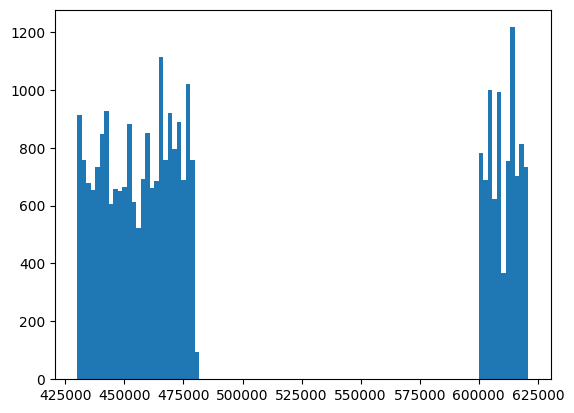

In [17]:
plt.hist(df_dropped['InsuredZipCode'], bins=100)
plt.show()

We can see that 'InsuredZipCode', a categorical feature, can be grouped by the first two digits of the Zip Code - if this proves to be still too many to One-Hot-Encode, we could even group them by the first digit.

In [18]:
df_dropped['InsuredZipCode'] = df_dropped['InsuredZipCode'].astype(str).apply(lambda x: x[:2]).astype(str)

###  d) Rescaling if necessary if necessary 


In [19]:
# The target column to use LabelBinarizer on
target_column = ['ReportedFraud']

# The columns to use OrdinalEncoder on
ordinal_columns = ['InsuredGender']

# The columns to use StandardScaler on
scaled_columns = ['InsuredAge', 'CapitalGains', 'CapitalLoss', 'NumberOfVehicles', 'BodilyInjuries'
                 , 'Witnesses', 'AmountOfTotalClaim', 'CustomerLoyaltyPeriod', 'Policy_Deductible', 'PolicyAnnualPremium'
                 , 'UmbrellaLimit', 'VehicleYOM', 'CapitalProfit', 'Policy_LowerSingleLimit'
                 , 'Policy_UpperSingleLimit','IncidentTime']

columns_to_drop = [] # Used during feature selection to trial the removal of certain feature subsets

# The columns to use OneHotEncoder on
onehot_columns = list(set(df_dropped.columns) - set(ordinal_columns) - set(target_column) \
                      - set(scaled_columns) - set(columns_to_drop))
print(onehot_columns)

['VehicleModel', 'AuthoritiesContacted', 'PoliceReport', 'SeverityOfIncident', 'TypeOfCollission', 'InsuredRelationship', 'PropertyDamage', 'InsuredOccupation', 'TypeOfIncident', 'VehicleMake', 'IncidentCity', 'InsurancePolicyState', 'InsuredHobbies', 'InsuredZipCode', 'InsuredEducationLevel']


In [20]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelBinarizer, label_binarize

# This is used so we don't attempt the same transformation on all the features
from sklearn.compose import ColumnTransformer

In [21]:
def preprocessing_transformer(scaled_columns, ordinal_columns, cols_to_drop, onehot_columns):
    prep_transformer = ColumnTransformer(transformers=[('standardscaler', StandardScaler(), scaled_columns)
                                                     ,('ordinalencoder', OrdinalEncoder(), ordinal_columns)
                                                     ,('onehotencoder', OneHotEncoder(), onehot_columns)]
                                                     ,remainder='drop')
    return prep_transformer

### e) Other

#### Preparing the training and test set parameters for the techniques
Note: due to the layout of the assignment, we will first use the sklearn provided tools of GridSearchCV, then we will use cross_validation in the final section where we compare the models

In [22]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import make_pipeline, Pipeline

In [23]:
# Defining a helper function to create X and y from the DataFrame

def separate_xy(df):
    y = label_binarize(df[target_column], classes=['N', 'Y']).ravel()
    df_X = df.replace(np.NaN, 'MISSING_DATA').drop(columns=target_column)
    
    #print(df[target_column][:5])
    #print(df_y[:5])
    
    return df_X, y

In [24]:
# Helper function to show performance metrics
def show_performance_metrics(y_test, y_pred, clf, normalize='pred', show=False):
    print(f'Balanced Accuracy is: {balanced_accuracy_score(y_test, y_pred)}')
    print(f'Precision and Recall are: {precision_recall_fscore_support(y_test, y_pred, average="weighted")[:2]}')
    print(f'Weighted F1_Score is: {f1_score(y_test, y_pred, pos_label=1, average="weighted")}')
    
    if show:
        cm = confusion_matrix(y_test, y_pred, normalize=normalize)
        conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
        conf_matrix.plot()
        plt.show()

In [25]:
X,y = separate_xy(df_dropped)

# Setting random_state=42 so that comments in report are consistent
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, shuffle=True, stratify=y, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(19234, 32) (19234,)
(9474, 32) (9474,)


#### Using the prepared pipelines to do additional feature selection / removal

We attempt to use a systematic approach to feature elimination (Tan et al., 2019) for those that are being considered for One-Hot encoding, as this expands dimensionality materially for each feature with multiple categorical labels.

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
iterate_columns = onehot_columns.copy()
precision_scores = []

for col in iterate_columns:
    columns_to_drop = [col]
    
    onehot_columns = list(set(df_dropped.columns) - set(ordinal_columns) - set(target_column) \
                      - set(scaled_columns) - set(columns_to_drop))

    prep_transformer = preprocessing_transformer(scaled_columns, ordinal_columns, columns_to_drop, onehot_columns)
    
    basic_clf = make_pipeline(prep_transformer, LogisticRegression(class_weight='balanced', max_iter=400))
    basic_model = basic_clf.fit(X_train, y_train)
    y_pred = basic_model.predict(X_train)
    
    precision_scores.append(1-precision_recall_fscore_support(y_train, y_pred, average='weighted')[0])

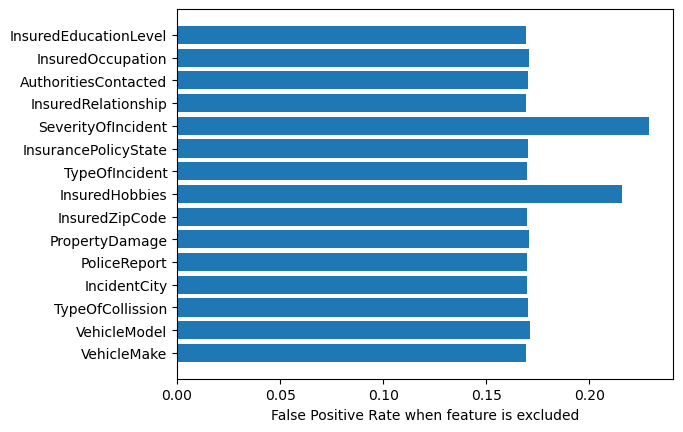

In [28]:
fig,ax = plt.subplots()
ax.barh(iterate_columns, precision_scores)
ax.set_xlabel('False Positive Rate when feature is excluded')
plt.show()

Based on the chart above, we can drop a number of columns without impacting the model's False Positive Rate performance (i.e. the proportion of customers falsely accussed of fraud) - the True Positive Rate would be 1-FPR.

In [29]:
cols_to_drop = ['InsuredEducationLevel', 'PoliceReport', 'VehicleModel', 'InsuredRelationship'
               , 'TypeOfCollission', 'VehicleMake', 'IncidentCity', 'InsuredZipCode'
               ,'InsuredOccupation', 'PropertyDamage', 'TypeOfIncident', 'AuthoritiesContacted']

onehot_columns = list(set(df_dropped.columns) - set(ordinal_columns) - \
                      set(target_column) - set(scaled_columns) - set(columns_to_drop))

prep_transformer = preprocessing_transformer(scaled_columns, ordinal_columns, cols_to_drop, onehot_columns)

## 4. Technique 1 (20 marks): LogisticRegression

### a) Discuss your motivation for choosing the technique and provide a schematic figure of the process

100-200 words


A LogisticRegression was chosen as the first technique as it is relatively quick to train but also allows for some more nuanced hyper-parameter tuning than a standard linear regression classifier.

In this technique, we have not transformed the input data into a feature space, as we did not find a visualisation that showed one type of transformation was required over another. Initially a translation with PolynomialFeatures was attempted, but was abandoned after the hyper-parameter tuning during grid-searching became exponentially longer to conduct.

### Logistic Regression Classification Schematic:
![LogReg_Schematic](Images\schematic_logreg.jpg)

In [30]:
from sklearn.linear_model import LogisticRegression

Enter the correct code in the cells below to execute each of the stated sub-tasks.
### b) Setting hyper parameters with rationale


- **class_weight**: 'balanced' is chosen here to combat the class imbalance as we have chosen not to tackle it at the data-level
- **max_iter**: default value of 100 is chosen as we believe that the chosen solver should converge within this limit
- **solver**: 'liblinear' is chosen as the sklearn documentation highlights that is it suitable for smaller datasets and is expected to converge faster than 'lbfgs'

In [31]:
# Using RFE to trim down the number of features
init_lgr = LogisticRegression(class_weight='balanced', max_iter=100, solver='liblinear')

lgr_clf = make_pipeline(prep_transformer, init_lgr)
lgr_model = lgr_clf.fit(X_train, y_train)
y_pred = lgr_model.predict(X_train)

# Evaluating the training of the model
show_performance_metrics(y_train, y_pred, init_lgr)

Balanced Accuracy is: 0.7995259351814685
Precision and Recall are: (0.8307491206337781, 0.8128314443173547)
Weighted F1_Score is: 0.8184133522306812


### c) Optimising hyper parameters


 - We will use GridSearchCV to optimise for this training set
 - Cross Validation is part of this process, but to preserve the assessment structure, we will implement Nested CV later and evaluate the model based on the training data only

#### Hyper-parameters to try:
- Changing the regularisation penalty (l1 vs l2) to see if that results in a better fit
- Changing the solver to determine if one solver has a stronger fit
- Changing the max iterations to account for solvers that may need more steps

In [32]:
logreg = LogisticRegression(class_weight='balanced', n_jobs=n_jobs)
logreg_pipe = Pipeline([('preprocessing', prep_transformer), ('logisticregression', logreg)])

lgr_params = {'logisticregression__max_iter' : [100,200,300]
         ,'logisticregression__penalty' : ['l1','l2']
         ,'logisticregression__solver' : ['lbfgs', 'liblinear', 'newton-cg']}

In [33]:
%%capture --no-display  
#%%timeit -n1 -r1
# Muting errors as some hyper-parameters will clash and create error messages

logreg_clf = GridSearchCV(logreg_pipe, param_grid = lgr_params, error_score=0)
logreg_model = logreg_clf.fit(X_train, y_train)
y_pred = logreg_model.predict(X_train)

### d) Performance metrics for training

For measuring performance, we will primarily use:
- **Weighted F1 Score**: F1 provides a more balanced (i.e. harmonic mean) view performance of the model across Detect and Recall ability; the weighted version allows us to better account for the class imbalance
- **Balanced Accuracy**: Balanced accuracy is used here to determine how well the model can identify the positive class within the provided dataset with class imbalance
- **Confusion Matrix**: This matrix is normalised by its Prediction so that we can get an indication of how well it might be able to find fraudulent customers in unseen data

Balanced Accuracy is: 0.799496801802385
Precision and Recall are: (0.8307955780127965, 0.813143391910159)
Weighted F1_Score is: 0.8186658380734458


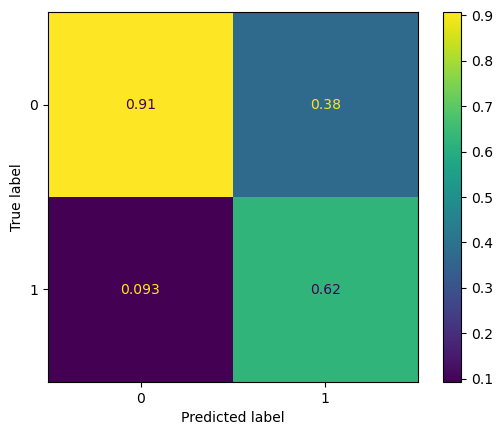

{'logisticregression__max_iter': 100, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'liblinear'}


In [34]:
show_performance_metrics(y_train, y_pred, logreg_clf, normalize='pred', show=True)
print(logreg_clf.best_params_)

As we can see from the above - the model is quite poor at picking up Fraudulent Customers; in fact, 38% of the customers it classified as Fraudulent were not Fraudulent.

Additionally, GridSearch was unable to find set of hyper-parameters that increased the strength of the fit. This could indicate that a fixed basis function may be required to further tune the model.

## 5. Technique 2 (20 marks)

### a) Discuss your motivation for choosing the technique and  provide a schematic figure of the process

100-200 words


A Multi-Layer Perceptron, or Neural Network, was chosen as the second technique. This technique allows greater flexibility in transforming the data into a 'feature space' that does not require the specification of a fixed basis function (Tan et al., 2019). We should expect a stronger fit from this Neural Network over the logistic regression algorithm; however, the main drawback of this algorithm is the increased training time required, which impacts the number of trials and therefore the breadth of hyper-parameters we can try during model tuning.

### Multi-Layer Perceptron Classification:
![MLPClassification_Schematic](Images\schematic_NN.jpg)

In [35]:
from sklearn.neural_network import MLPClassifier

Enter the correct code in the cells below to execute each of the stated sub-tasks.
### b) Setting hyper parameters with rationale


- **hidden_layer_sizes**: we kept this at the default value to see what kind of fit we may get; this would be a decisive hyper-parameter in increasing fit, but we must also be mindful of the compute time
- **activation**: this was changed from 'relu' to 'logistic', just to see how it compares to the Logistic Regression used earlier
- **solver**: we are using Stochastic Gradient Descent as it will hopefully allow us to more readily avoid and escape local minima; additionally, we are likely to use this model in a stochastic manner in production, as new customers are added to the database in a stream
- **max_iter**: increased to 500 to maximies the probability of convergence
- **learning_rate**: set to adaptive so that we can better fine-tune the sgd approach if validation scores stagnate

In [36]:
mlp_clf = make_pipeline(prep_transformer,
                        MLPClassifier(hidden_layer_sizes = (100,), activation='logistic',
                                      solver='sgd', learning_rate='adaptive', max_iter=500))

In [37]:
%%timeit -n1 -r1

mlp_model = mlp_clf.fit(X_train, y_train)
y_pred = mlp_model.predict(X_test)

show_performance_metrics(y_test, y_pred, mlp_clf)

Balanced Accuracy is: 0.7806287422712672
Precision and Recall are: (0.8432160362671465, 0.8482161705720921)
Weighted F1_Score is: 0.8434649950929111
34.1 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


At first glance, this model has not been able to meet the Logistic Regression model for its balanced accuracy score; however, through GridSearch we may find a stronger fit.

### c) Optimising hyper parameters


In [38]:
mlp_pipe = Pipeline([('preprocessing', prep_transformer), ('mlp', MLPClassifier(max_iter=1000, early_stopping=True))])
mlp_params = {'mlp__hidden_layer_sizes' : [(200,), (100,100,100), (150, 150)]
         ,'mlp__activation' : ['logistic', 'relu']
         ,'mlp__solver' : ['sgd', 'lbfgs', 'adam']
         ,'mlp__learning_rate' : ['adaptive', 'constant']}

In [39]:
#Limiting GridSearchCV to 3 folds to save on compute time
mlp_clf = GridSearchCV(mlp_pipe, mlp_params, error_score=0, cv=3, n_jobs=n_jobs)
mlp_model = mlp_clf.fit(X_train, y_train)
y_pred = mlp_model.predict(X_train)

### d) Performance metrics for training

Balanced Accuracy is: 0.9092640908443501
Precision and Recall are: (0.9421032808459867, 0.9421337215347821)
Weighted F1_Score is: 0.9410266990217476


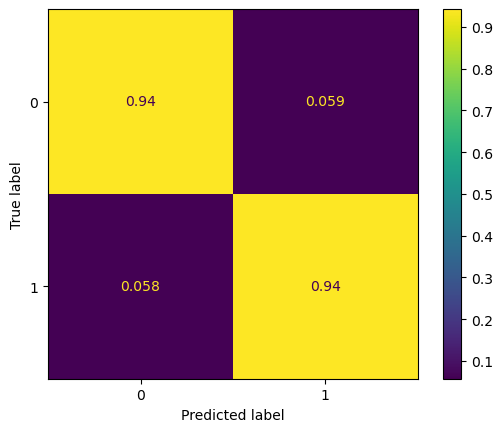

{'mlp__activation': 'relu', 'mlp__hidden_layer_sizes': (200,), 'mlp__learning_rate': 'constant', 'mlp__solver': 'adam'}


In [40]:
show_performance_metrics(y_train, y_pred, mlp_clf, normalize='pred', show=True)
print(mlp_clf.best_params_)

GridSearch provides us with a clue that a loigstic activation function using the adam solver provides the best fit (for the training set), along with 1 hidden layer with 200 neurons (rather than more layers with fewer neurons) - though extending this further may result in overfitting.

## 6. Comparison of metrics performance for testing (16 marks)
Enter the correct code in the cells below to execute each of the stated sub-tasks. 


### a) Use of cross validation for both techniques to deal with over-fitting

To retrieve the generalised performance for these two models so that we can compare them, we will put the algorithms into a nested cross-validation process and then retrieve their AUC from the ROC curve (Tan et al., 2019)

Finally, we will use the partitioned testing set to reconfirm the generalised performance of the model - though we note that the test set is only one instance and may itself contain biases; however, pairing this with the nested cross validation should give us an indication of the generalised performance of the models

In [65]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
# Default n_splits=5 is used to balance finding variance/bias in the folds and compute time - particularly for MLP
inner_cv = StratifiedKFold(shuffle=True, random_state=42) 
outer_cv = StratifiedKFold(shuffle=True, random_state=42)

scoring = {'bal_acc' : 'balanced_accuracy'
          ,'f1' : 'f1_weighted'
          ,'detect' : 'precision'
          ,'roc_auc' : 'roc_auc_ovo_weighted'}

In [42]:
#%%timeit -n1 -r1
# Running nested cv for the LogisticRegression model
logreg_clf = GridSearchCV(logreg_pipe, param_grid=lgr_params, error_score=0, cv=inner_cv, n_jobs=n_jobs, refit=True)
logreg_nested_cv = cross_validate(logreg_clf, X=X_train, y=y_train, cv=outer_cv, n_jobs=n_jobs, scoring=scoring)

In [43]:
# Running nested cv for the Neural Network model
# WARNING! Will take a long time (30+ mins depending on hardware)
mlp_clf = GridSearchCV(mlp_pipe, mlp_params, error_score=0, cv=inner_cv, n_jobs=n_jobs)
mlp_nested_cv = cross_validate(mlp_clf, X=X_train, y=y_train, cv=outer_cv, n_jobs=n_jobs, scoring=scoring)

### b) Comparison with appropriate metrics for testing

The main metric we are interested in here is the Predict / Precision score:
$$Predict = \frac{TP}{TP+FP}$$
This is because while we want to find as many fraudsters as possible, we are also concerned with minimising the proportion of genuine customers being falsely accused (i.e.  $1- Predict$ or False Positive rate)

In [ ]:
logreg_detect = logreg_nested_cv['test_predict']
mlp_detect = mlp_nested_cv['test_predict']
x_ticks = np.arange(1, len(mlp_detect)+1, 1)

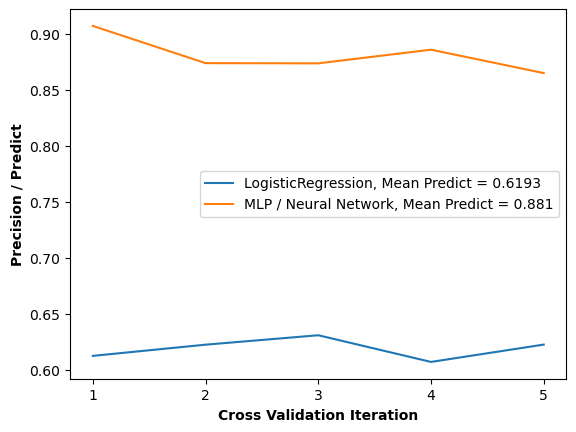

In [75]:
plt.plot(x_ticks, logreg_detect, label=f'LogisticRegression, Mean Predict = {round(logreg_detect.mean(), 4)}')
plt.plot(x_ticks, mlp_detect, label=f'MLP / Neural Network, Mean Predict = {round(mlp_detect.mean(), 4)}')
plt.xticks(ticks=x_ticks)
plt.xlabel('Cross Validation Iteration', fontweight='bold')
plt.ylabel('Precision / Predict', fontweight='bold')
plt.legend()
plt.show()

We can see that the MLP / Neural Network Classifier performed much better over the cross validation, though its generalised error rate is lower than that when evaluated against the training data (this is expected).

### c) Model selection (ROC or other charts)

In [45]:
from sklearn.metrics import roc_curve, RocCurveDisplay

In [46]:
%%capture --no-display
# Suppressing errors due to clash between solver=liblinear and having an n_jobs parameter set

best_logreg = logreg_clf.fit(X_train, y_train)
y_pred_lgr =  best_logreg.predict(X_test)

In [47]:
best_mlp = mlp_clf.fit(X_train, y_train)
y_pred_mlp =  best_mlp.predict(X_test)

In [48]:
lgr_fpr, lgr_tpr, lgr_thresholds = roc_curve(y_test, y_pred_lgr, pos_label=1)
lgr_auc = roc_auc_score(y_test, y_pred_lgr)


mlp_fpr, mlp_tpr, mlp_thresholds = roc_curve(y_test, y_pred_mlp, pos_label=1)
mlp_auc = roc_auc_score(y_test, y_pred_mlp)

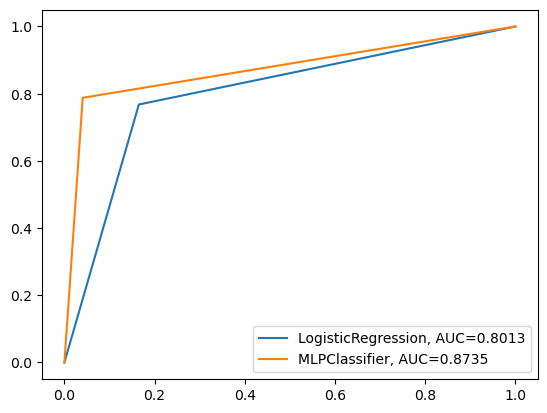

In [49]:
plt.plot(lgr_fpr, lgr_tpr, label=f'LogisticRegression, AUC={round(lgr_auc, 4)}')
plt.plot(mlp_fpr, mlp_tpr, label=f'MLPClassifier, AUC={round(mlp_auc, 4)}')
plt.legend()
plt.show()

Based on the ROC curves and the cross-validated precision screos, we would select the Neural Network / MLP Classifier model as the recommended model to put into production, if the project were to progress.

Balanced Accuracy is: 0.8735471813894513
Precision and Recall are: (0.9117325729293841, 0.9130251213848427)
Weighted F1_Score is: 0.9114862473957513


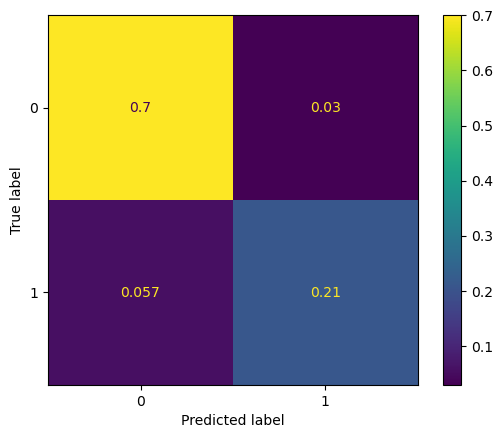

In [55]:
show_performance_metrics(y_test, y_pred_mlp, best_mlp, normalize='all', show=True)


In [51]:
cm = confusion_matrix(y_test, y_pred_mlp, normalize='all')
tpr=cm[1,1]
tnr=cm[0,0]
fpr = cm[0,1]
fnr = cm[1,0]
print(f'TPR: {tpr}, TNR: {tnr}')
print(f'FPR: {fpr}, FNR: {fnr}')

TPR: 0.21268735486594892, TNR: 0.7003377665188938
FPR: 0.0296601224403631, FNR: 0.057314756174794174


## 7. Final recommendation of best model (8 marks)

### a) Discuss the results from a technical perspective, for example, overfitting discussion, complexity and efficiency

100-200 words


### b) Discuss the results from a business perspective, for example, results interpretation, relevance and balance with technical perspective

100-200 words

To determine the profit impact on the business, we will assume:
- 10% of total customer base claims
- Profit = 2x Total Claim Amount
- We can take the average value of the claims
- We can calculate the average value of the policy
- Any customers we lose because of incorrect flagging will not have claimed any insurance
- All policies have been paid for already, any lost revenue will be from next years' revenue

### Calculating the required cost for a policy
$$
\begin{align}
\textrm{Profit} &= \textrm{Revenue} - \textrm{Cost}
\\
2 \times \textrm{total_claim_amount} &= \textrm{(avg_policy_revenue } \times \textrm{ num_customers) - (total_claim_amount)}
\\
\therefore \textrm{avg_policy_revenue} &= \frac{3 \times \textrm{total_claim_amount}}{\textrm{num_customers}}
\end{align}
$$

In [52]:
avg_claim_amount = round(df_joined['AmountOfTotalClaim'].astype(float).mean() , 2)
total_claim_amount = round(df_joined['AmountOfTotalClaim'].astype(float).sum(), 2)
print(f'Average claim amount: {avg_claim_amount:,}')
print(f'Total amount claimed: {total_claim_amount:,}')

total_customers = len(df_joined['AmountOfTotalClaim']) * 10
print(f'Estimated Total Customer Base Size: {total_customers:,}')

required_profit = round(2*total_claim_amount, 2)
print(f'Required Total Profit: {required_profit:,}')

avg_policy_revenue = round(3*total_claim_amount/total_customers, 2)
print(f'Required Average Policy Price: {avg_policy_revenue:,}')

print(f'The ratio of average fraud cost to average policy revenue is: {round(avg_claim_amount/avg_policy_revenue,2):,}')

missclassified_lost_customers = round(total_customers * 0.1 * fpr)
print(f'Number of customers falsely accused of fraud: {missclassified_lost_customers:,}')

missclassified_lost_revenue = round(missclassified_lost_customers * avg_policy_revenue, 2)
print(f'Revenue lost due to falsely accussed customers leaving: {missclassified_lost_revenue:,}')

found_fraudsters = round(total_customers * 0.1 * tpr)
print(f'Number of fraudsters found: {found_fraudsters:,}')

print(f'Ratio of missclassified genuine customers to fraudsters found is: {round(missclassified_lost_customers/found_fraudsters, 2):,}')

saved_fraud_costs = round(found_fraudsters * avg_claim_amount, 2)
print(f'Total false claim costs saved: {saved_fraud_costs:,}')

Average claim amount: 52,308.55
Total amount claimed: 1,505,753,790.0
Estimated Total Customer Base Size: 288,360
Required Total Profit: 3,011,507,580.0
Required Average Policy Price: 15,665.35
The ratio of average fraud cost to average policy revenue is: 3.34
Number of customers falsely accused of fraud: 855
Revenue lost due to falsely accussed customers leaving: 13,393,874.25
Number of fraudsters found: 6,133
Ratio of missclassified genuine customers to fraudsters found is: 0.14
Total false claim costs saved: 320,808,337.15


In [53]:
profit_impact = round(saved_fraud_costs - missclassified_lost_revenue, 2)
print(f'Total Profit Impact of implementing this classifier: {profit_impact:,}')

Total Profit Impact of implementing this classifier: 307,414,462.9


*(Note: currency is assumed to be Indian Rupees due to the country being India)*

As we can see, even though the desired error rate was not acheived, the business will still have a net-positive outcome when implementing this classification model. This outcome was driven by three factors:
1. Fraudulent claims are already costing the business today - any frauds missed by the classifier (the error rate suggests that this represents ~3% of total customers - i.e. the False Positive Rate) won't impact the calculations here
2. A fraudulent customer costs the business ~3 times the revenue of a genuine customer - this classifier only missclassifies 0.15 genuine customers for every fraud found
3. Because we have used data from customers that have tried to claim insurance, we can only do this classification when a claim from an existing customer comes in - this also has two benefits:
 - We can continue to collect Policy Revenue from fraudulent customers before they try to claim
 - We minimise the risk of classifying genuine customers as fraudulent before they try to claim

### Concluding remarks
If the busines implements this model, we should expect profit to increase (i.e. saved costs far outweigh lost revenue); however, there are other considerations that must be taken into account:
- The generalised error may change once the model goes into production (i.e. new datapoints are introduced)
- The long-term impact to reputation and revenue has not been calculated
- Further refinements to this model are suggested

### Recommendation
I would recommend that the business implement this model on a phased basis, so that the generalised error can be measured with more datapoints and the model improved on with additional datapoints. A phased implementation on select geographies will limit the number of customers impacted and customer complaints - this will allow the customer service team to handle complaints. Additionally, with the saved costs, the business could generously reimburse or compensate misclassified customers to mitigate the probability of losing that revenue; alternatively, the saved costs could go towards the acquisition of new customers.

## 8. Conclusion (8 marks)

### a) What has been successfully accomplished and what has not been successful?
100-300 words

In this project, we have successfully identified two models which could be used for classifying future customers (or other non-classified, existing customers) on whether they exihibit behaviours or attributes that are in line with customers that have been fraudulent in the past.

Unfortunately, we have not fit the model to the error threshold required by the business, which means that the cost to the business is higher than is willing to be accepted. This may be due to the feature selection and feature engineering processes - namely, there is scope to conduct deeper analysis on the features and to either exclude more features (that could have been 'noisy') and also to transform the features different. For example, the approach taken in this project was to encode 'Missing Data' as a type of value rather than to impute those values in a different way.

### b) Reflecting back on the analysis, what could you have done differently if you were to do the project again?

100-300 words

There were several shortcomings in this project, which should be revisited if this were to be re-taken:

1. **More rigorous handling of missing data**: In this project, we treated missing data as a type of additional label for that feature; however, it may have been better to have used some form of classification technique to impute the missing data, which may have led to a stronger fit



2. **Experiment with balancing the classes at the data-level**: Class imbalance was only managed by choosing models (or model settings) that are more robust against class imbalance; however, we could also have:
    - Over-sampled the minority class, or
    - Under-sampled the majority class, or
    - Created synthetic datapoints in the minority class, or
    - Aggregated datapoints in the majority class, or
    

3. **More rigorous feature selection**: The importance and time taken for data preparation was underestimated, and more experimentation with feature selection tools (e.g. Recursive Feature Elimination, Correlation Matrix for continuous data types) should have been undertaken, this would have:
    - Led to higher degree of confidence in the quality of the base data
    - Potentially reduced dimensionality of the dataset, decreasing model training time and increasing experimentation
    - Potentially eliminated the 'noisier' features, which may have led to a stronger fit
    

4. **More time spent on feature extraction**: The model may have been confused by certain attributes that needed more preprocessing to simplify the dataset and reduced noise
    - 'InsuredZipCode' would have benefited from some form of clustering technique to reduce its dimensionality; it is technically a nominal data type, which would have benefited replacing the exact zip codes with an 'averaged' value for its cluster (i.e. centroid)
    

5. **Choosing a more time-efficient model**: The second technique used in this project was the Neural Network, which while flexible, also took more time to train than other models (e.g. distance-weighted kNN); if a more time-efficient model was selected, the time saved could have been put towards greater fine-tuning of hyper-parameters and feature selection processes that may have resulted in a stronger fit

### c) Provide a wish list of future work that you would like to do

100-200 words

A list of future work **related to this project** would include:
- Conduct Clustering 'InsuredZipCode' to reduce the cardinality of the feature to something that could be One Hot Encoded
- Try replacing 'InsuredZipCode' with lat-lon geographic data to cluster the feature on actual proximity rather than the Zip Code itself
- Utilised feature selection tools such as RFE to determine the best features to use in the modelling
- Experiment with balancing the classes at a data-level (e.g. under/over-sampling)
    - This would also enable more classifier types (e.g. kNN)
- Impute missing categorical data with classification techniques (e.g. using LogisticRegression on 'PoliceReport')

# References
 1. Tan, P., Steinbach, M., Karpatne, A. and Kumar, V. (2019). *Introduction to Data Mining. Second Edition.* New York: Pearson